## 4. 시계열 분석 (월별, 계절별 변화)

**분석 목표:**
- 시간에 따른 오염도 변화 추이를 파악하여 계절별 패턴과 장기 추세를 분석합니다.

**분석 항목:**
- DO, BOD, COD, TP, TN (5개 지표)
- 시간 범위: 2023년 07월 ~ 2026년 06월 (3년)

**분석 방법:**
- 월별 (36개월)
- 계절별 (4계절)
- 년도별 (3년)

**주요 시각화:**
- 시계열 시각화 (라인 플롯 3가지)

In [48]:
# ===== 지점별 시계열 분석 (월별, 모든 지점 한 그래프) =====
point_order = ['팔당댐2', '성내천', '보광', '노량진', '영등포']

# 지점별 평균값 (상류→하류)
point_avg = df.groupby('측정소명')[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean().reset_index()
point_avg['측정소명'] = pd.Categorical(point_avg['측정소명'], categories=point_order, ordered=True)
point_avg = point_avg.sort_values('측정소명')

print("✅ 지점별 평균값 (상류→하류)")
print()
print(point_avg.to_string(index=False))
print("\n" + "="*80 + "\n")

✅ 지점별 평균값 (상류→하류)

측정소명   DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
팔당댐2 11.276875  1.066875  3.302500 0.033469 2.481450
 성내천  9.302941  1.841176  4.088235 0.084588 2.671029
  보광  9.706250  2.118750  4.468750 0.051375 3.813719
 노량진 11.043750  1.921875  4.315625 0.082437 4.261063
 영등포 10.078788  1.842424  4.366667 0.045152 3.501303




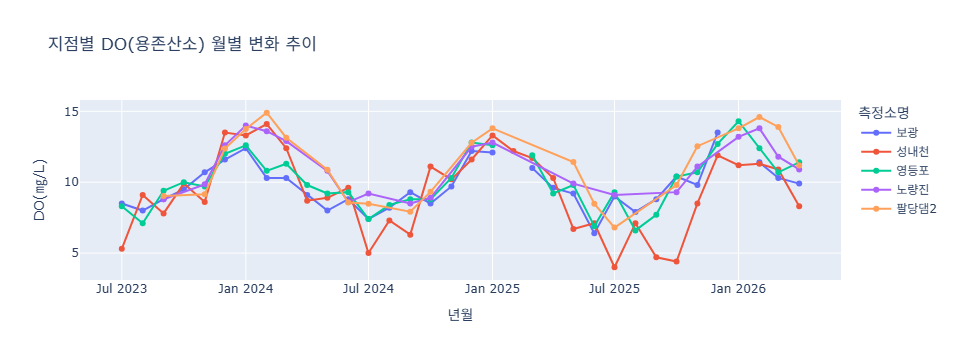

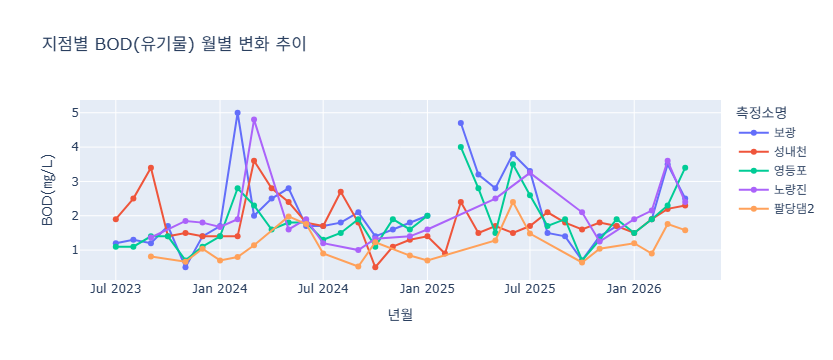

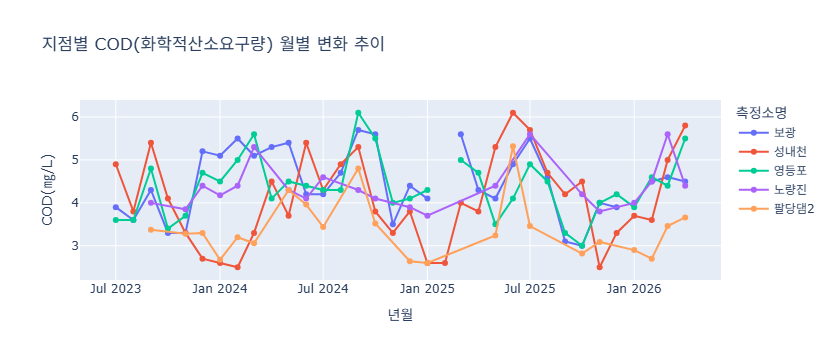

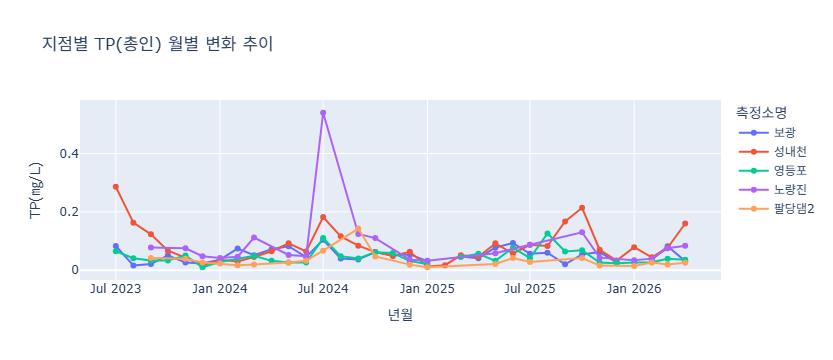

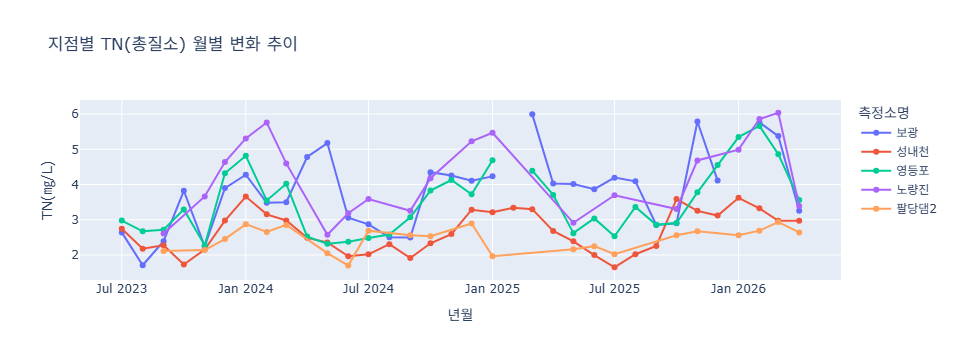

In [49]:
# 지점별 월별 시계열 시각화 (5개 지점 한 그래프)
fig_do = px.line(monthly, x='년월', y='DO(㎎/L)', color='측정소명',
                 title='지점별 DO(용존산소) 월별 변화 추이', markers=True)
fig_do.show()

fig_bod = px.line(monthly, x='년월', y='BOD(㎎/L)', color='측정소명',
                  title='지점별 BOD(유기물) 월별 변화 추이', markers=True)
fig_bod.show()

fig_cod = px.line(monthly, x='년월', y='COD(㎎/L)', color='측정소명',
                  title='지점별 COD(화학적산소요구량) 월별 변화 추이', markers=True)
fig_cod.show()

fig_tp = px.line(monthly, x='년월', y='TP(㎎/L)', color='측정소명',
                 title='지점별 TP(총인) 월별 변화 추이', markers=True)
fig_tp.show()

fig_tn = px.line(monthly, x='년월', y='TN(㎎/L)', color='측정소명',
                 title='지점별 TN(총질소) 월별 변화 추이', markers=True)
fig_tn.show()


In [26]:
# ===== 데이터 로드 및 전처리 =====
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('./data/processed/hangang_final.csv')
df['년/월/일'] = pd.to_datetime(df['년/월/일'])
df['년월'] = df['년/월/일'].dt.to_period('M')
df['년도'] = df['년/월/일'].dt.year

# 계절 구분
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df['계절'] = df['년/월/일'].dt.month.apply(get_season)

# 월별 평균값 (그래프용)
monthly = df.groupby(['년월', '측정소명'])[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean().reset_index()
monthly['년월'] = monthly['년월'].dt.to_timestamp()

In [42]:
# ===== 계절별 평균값 =====
seasonal_avg = df.groupby(['계절', '측정소명'])[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean().reset_index()

# 계절 순서 정렬 (봄→여름→가을→겨울)
season_order = {'봄': 1, '여름': 2, '가을': 3, '겨울': 4}
seasonal_avg['season_num'] = seasonal_avg['계절'].map(season_order)
seasonal_avg = seasonal_avg.sort_values('season_num')

yearly = df.groupby(['년도', '측정소명'])[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean().reset_index()
yearly['년도'] = yearly['년도'].astype(str)

print("✅ 계절별 평균값")
print()

# 계절별로 나눠서 출력
for season in ['봄', '여름', '가을', '겨울']:
    season_data = seasonal_avg[seasonal_avg['계절'] == season][['계절', '측정소명', 'DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']]
    print(f"【{season}】")
    print(season_data.to_string(index=False))
    print()


✅ 계절별 평균값

【봄】
계절 측정소명  DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
 봄 팔당댐2  12.1040    1.5480    3.5440 0.022360 2.529240
 봄  영등포  10.4125    2.4625    4.6625 0.039375 3.500750
 봄  성내천   9.7375    2.3625    4.4250 0.078500 2.767375
 봄   보광   9.6750    3.0000    4.8625 0.060500 4.514500
 봄  노량진  11.2600    2.9800    4.8000 0.076200 3.903600

【여름】
계절 측정소명  DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
여름 팔당댐2   8.0800    1.6350    4.0450 0.042400 2.165900
여름  성내천   6.8125    1.9875    4.9750 0.129750 2.110000
여름   보광   8.0250    2.0375    4.4500 0.062125 3.117250
여름  노량진   9.0000    2.4000    4.9750 0.190500 3.542500
여름  영등포   7.9125    1.8250    4.2125 0.066750 2.752125

【가을】
계절 측정소명  DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
가을  노량진 9.400000  1.450000  4.008333 0.087667 3.635333
가을 팔당댐2 9.680000  0.890000  3.420000 0.046617 2.390167
가을  영등포 9.533333  1.366667  4.200000 0.048222 3.206778
가을  성내천 7.944444  1.655556  4.044444 0.097667 2.455222
가을   보광 9.500000  1.333333  3.977778 0

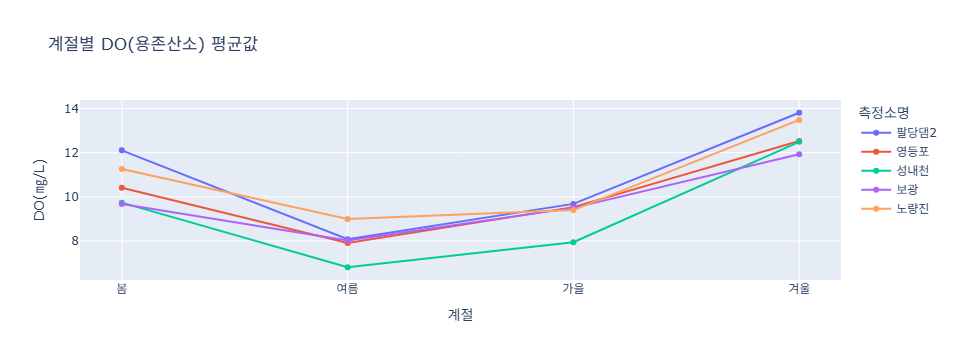

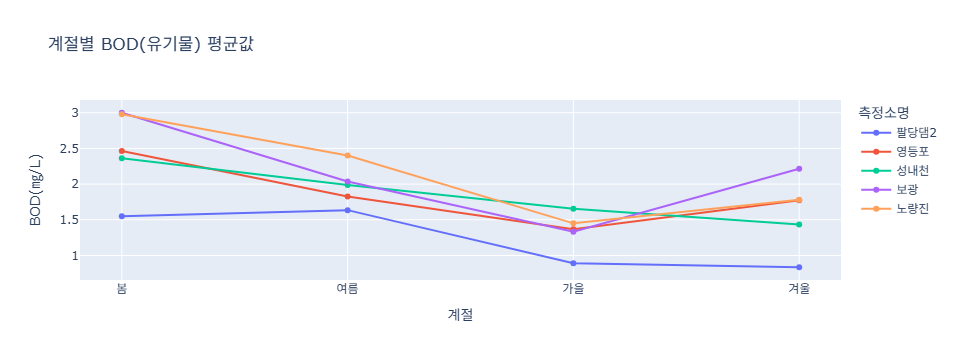

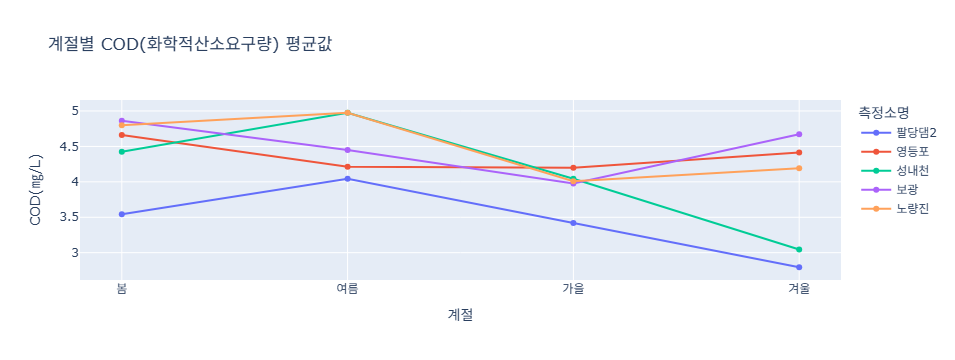

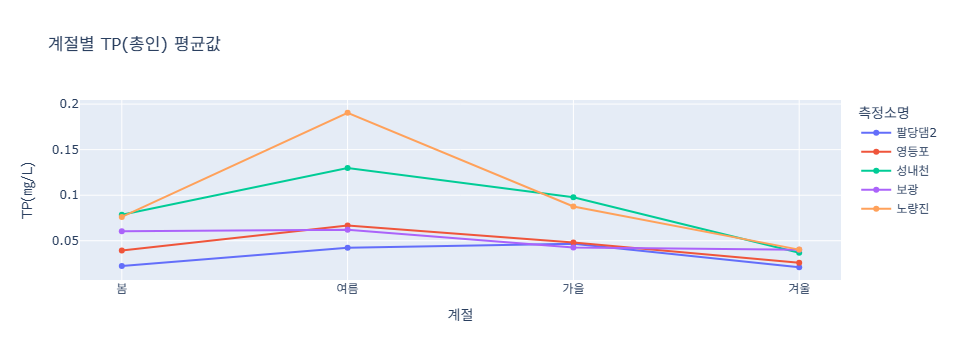

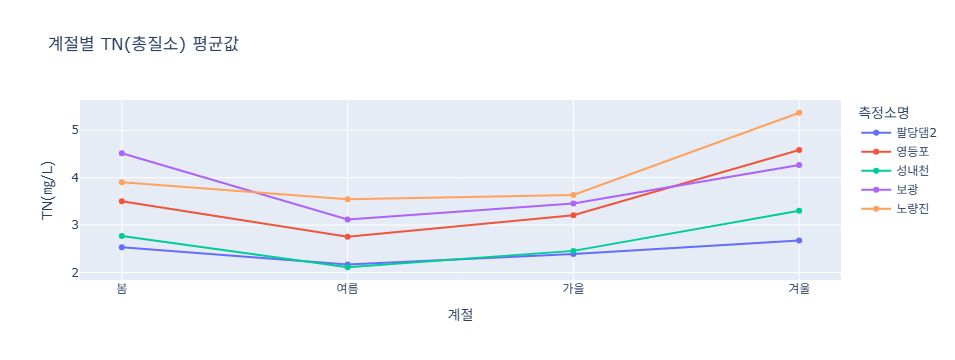

In [43]:

# 계절별 시계열 시각화 (5개 지표)
fig_do = px.line(seasonal_avg, x='계절', y='DO(㎎/L)', color='측정소명',
                 title='계절별 DO(용존산소) 평균값', markers=True,
                 category_orders={'계절': ['봄', '여름', '가을', '겨울']})
fig_do.show()

fig_bod = px.line(seasonal_avg, x='계절', y='BOD(㎎/L)', color='측정소명',
                  title='계절별 BOD(유기물) 평균값', markers=True,
                  category_orders={'계절': ['봄', '여름', '가을', '겨울']})
fig_bod.show()

fig_cod = px.line(seasonal_avg, x='계절', y='COD(㎎/L)', color='측정소명',
                  title='계절별 COD(화학적산소요구량) 평균값', markers=True,
                  category_orders={'계절': ['봄', '여름', '가을', '겨울']})
fig_cod.show()

fig_tp = px.line(seasonal_avg, x='계절', y='TP(㎎/L)', color='측정소명',
                 title='계절별 TP(총인) 평균값', markers=True,
                 category_orders={'계절': ['봄', '여름', '가을', '겨울']})
fig_tp.show()

fig_tn = px.line(seasonal_avg, x='계절', y='TN(㎎/L)', color='측정소명',
                 title='계절별 TN(총질소) 평균값', markers=True,
                 category_orders={'계절': ['봄', '여름', '가을', '겨울']})
fig_tn.show()

In [40]:
# ===== 년도별 평균값 =====
yearly = df.groupby(['년도', '측정소명'])[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean().reset_index()

print("✅ 년도별 평균값")
print()

# 년도별로 나눠서 출력
for year in sorted(df['년도'].unique()):
    year_data = yearly[yearly['년도'] == year][['측정소명', 'DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']]
    print(f"【{year}년】")
    print(year_data.to_string(index=False))
    print()

✅ 년도별 평균값

【2023년】
측정소명  DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
 노량진 9.783333  1.600000  4.016667 0.071667 3.299667
  보광 9.516667  1.216667  3.933333 0.036667 2.784500
 성내천 9.033333  2.016667  4.033333 0.116333 2.342833
 영등포 9.416667  1.133333  3.966667 0.038667 3.042667
팔당댐2 9.630000  0.800000  3.330000 0.038067 2.177400

【2024년】
측정소명   DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
 노량진 11.342857     1.750  4.278571 0.104000 4.426143
  보광  9.516667     2.175  4.891667 0.058917 3.738583
 성내천  9.875000     1.875  3.950000 0.074000 2.587250
 영등포  9.958333     1.750  4.700000 0.045833 3.284417
팔당댐2 11.401429     1.030  3.332857 0.039757 2.608329

【2025년】
측정소명   DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
 노량진 10.342857  2.171429  4.442857 0.068571 4.064571
  보광  9.790909  2.409091  4.281818 0.051727 4.188727
 성내천  8.491667  1.675000  4.108333 0.077500 2.734667
 영등포  9.800000  2.172727  4.136364 0.052727 3.494455
팔당댐2 10.768571  1.225714  3.374286 0.024886 2.329457

【2026년】
측정소명  

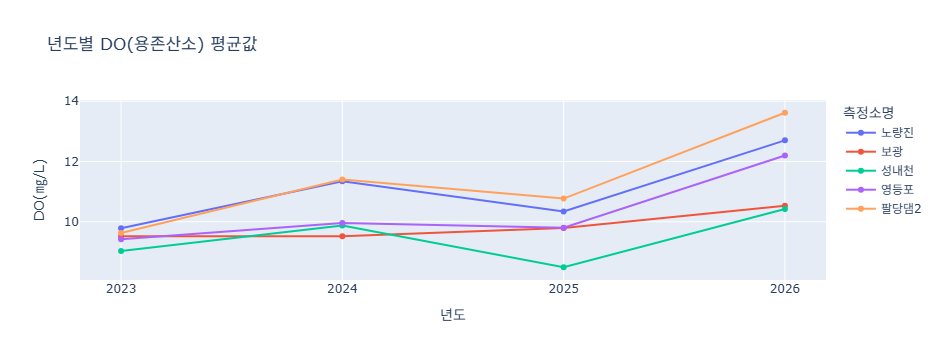

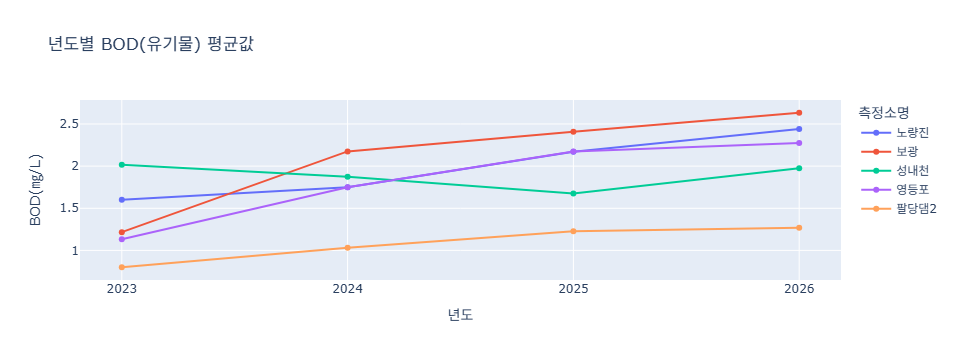

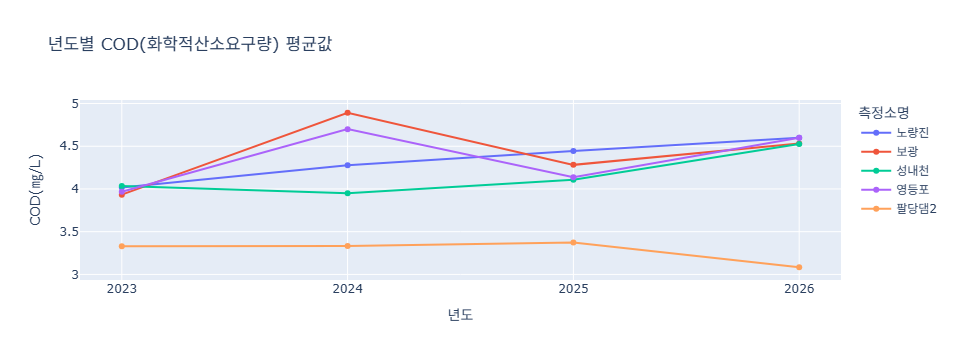

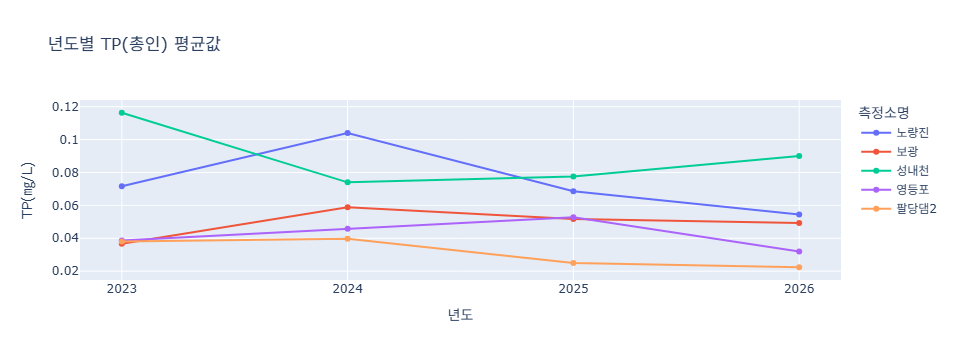

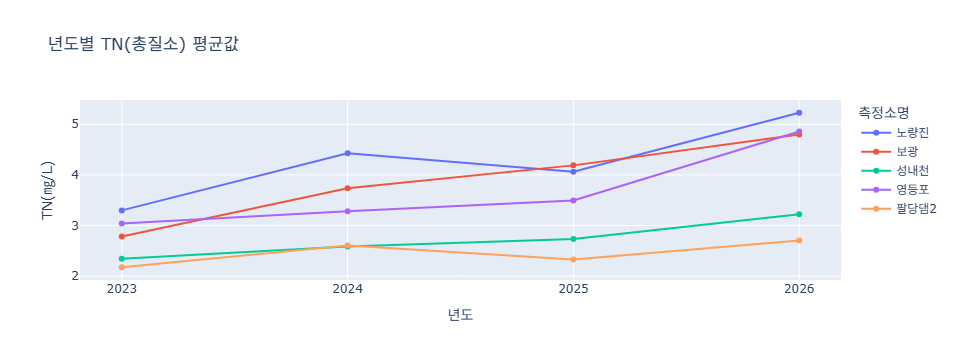

In [44]:

# 년도별 시계열 시각화 (5개 지표)
year_order = sorted(yearly['년도'].unique())

fig_do = px.line(yearly, x='년도', y='DO(㎎/L)', color='측정소명',
                 title='년도별 DO(용존산소) 평균값', markers=True)
fig_do.show()

fig_bod = px.line(yearly, x='년도', y='BOD(㎎/L)', color='측정소명',
                  title='년도별 BOD(유기물) 평균값', markers=True)
fig_bod.show()

fig_cod = px.line(yearly, x='년도', y='COD(㎎/L)', color='측정소명',
                  title='년도별 COD(화학적산소요구량) 평균값', markers=True)
fig_cod.show()

fig_tp = px.line(yearly, x='년도', y='TP(㎎/L)', color='측정소명',
                 title='년도별 TP(총인) 평균값', markers=True)
fig_tp.show()

fig_tn = px.line(yearly, x='년도', y='TN(㎎/L)', color='측정소명',
                 title='년도별 TN(총질소) 평균값', markers=True)
fig_tn.show()



## 📊 분석 해석

### 🔹 DO(용존산소)
- **수치 현황:** 여름 13 ~ 15 → 겨울 5 ~ 8 mg/L (뚜렷한 계절 변화)
- **특징:** 상류(팔당댐2)가 가장 높고, 지류(성내천)가 가장 낮음. 모든 지점 항상 7.5mg/L 이상 유지로 Ia등급 안정적.
- **평가:** 전 지점 Ia등급으로 산소 포화도 우수 ✅

---

### 🔹 BOD(유기물)
- **수치 현황:** 평균 1.07 ~ 2.12 mg/L, 성내천이 다른 지점보다 높음
- **특징:** 겨울에 높은 경향 (수온 저하로 분해 저하). 2024년 1월 성내천에서 스파이크.
- **평가:** 증가 추세 있으나 모든 지점 II등급 이내로 양호 ✅

---

### 🔹 TP(총인)
- **수치 현황:** 팔당댐2 0.0335 mg/L → 성내천 0.0846 mg/L (상류→하류 증가)
- **특징:** 2024년 7월 성내천에서 이상치 발생. 계절 변화는 미미.
- **평가:** 상류 → 하류 증가 추세 주목, 성내천 오염원 관리 필요 ⚠️

---

### 🔹 TN(총질소) - 참고용
- **수치 현황:** 팔당댐2 2.48 mg/L → 노량진 4.26 mg/L (약 1.7배 증가)
- **특징:** 뚜렷한 상류→하류 증가 패턴. 하천수 환경기준 없음.
- **평가:** 영양염 축적 추세 명확, 장기 모니터링 필요 📊

---

### 🔹 계절별 특성
- **여름(6 ~ 8월):** DO 최고(13 ~ 15mg/L), BOD 최저(0.8 ~ 1.2)mg/L → 최고 수질
- **겨울(12 ~ 2월):** DO 최저(5 ~ 8mg/L), BOD 최고(2.0 ~ 3.0mg/L) → 최저 수질
- **봄/가을:** 중간 수준, 안정적

---

### 🎯 박스플롯과의 비교
- 시계열 분석(##4): 시간에 따른 변화 추이 관찰 → 계절 패턴 & 장기 추세 발견
- 박스플롯(##2): 분포의 형태 & 변동성 관찰 → 데이터 퍼짐 정도 파악